In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/PyAi/house prices.csv')
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.shape

(1460, 81)

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Length: 1460, dtype: bool

In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [9]:
df.dropna()
df.count()

Id               1460
MSSubClass       1460
MSZoning         1460
LotFrontage      1201
LotArea          1460
                 ... 
MoSold           1460
YrSold           1460
SaleType         1460
SaleCondition    1460
SalePrice        1460
Length: 81, dtype: int64

In [11]:
df.drop(columns=['Id', 'MSSubClass', 'LotFrontage', 'OverallQual', 'OverallCond', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'LandContour','MasVnrType','ExterQual','ExterCond','Foundation','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','HeatingQC','CentralAir','Electrical','1stFlrSF','2ndFlrSF','LowQualFinSF','GrLivArea','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','TotRmsAbvGrd','Functional','Fireplaces','FireplaceQu','GarageType','GarageYrBlt','GarageFinish','GarageCars','GarageArea','GarageQual','GarageCond','PavedDrive','WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','PoolQC','Fence','MiscFeature','MiscVal','YrSold','MoSold','SaleType','SaleCondition','PoolArea','ScreenPorch','Alley','Heating','KitchenQual'], inplace=True)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   MSZoning      1460 non-null   str  
 1   LotArea       1460 non-null   int64
 2   Street        1460 non-null   str  
 3   LotShape      1460 non-null   str  
 4   Utilities     1460 non-null   str  
 5   HouseStyle    1460 non-null   str  
 6   YearBuilt     1460 non-null   int64
 7   RoofStyle     1460 non-null   str  
 8   BedroomAbvGr  1460 non-null   int64
 9   KitchenAbvGr  1460 non-null   int64
 10  SalePrice     1460 non-null   int64
dtypes: int64(5), str(6)
memory usage: 125.6 KB


In [14]:
df

,MSZoning,LotArea,Street,LotShape,Utilities,HouseStyle,YearBuilt,RoofStyle,BedroomAbvGr,KitchenAbvGr,SalePrice
0,RL,8450,Pave,Reg,AllPub,2Story,2003,Gable,3,1,208500
1,RL,9600,Pave,Reg,AllPub,1Story,1976,Gable,3,1,181500
2,RL,11250,Pave,IR1,AllPub,2Story,2001,Gable,3,1,223500
3,RL,9550,Pave,IR1,AllPub,2Story,1915,Gable,3,1,140000
4,RL,14260,Pave,IR1,AllPub,2Story,2000,Gable,4,1,250000
...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,7917,Pave,Reg,AllPub,2Story,1999,Gable,3,1,175000
1456,RL,13175,Pave,Reg,AllPub,1Story,1978,Gable,3,1,210000
1457,RL,9042,Pave,Reg,AllPub,2Story,1941,Gable,4,1,266500
1458,RL,9717,Pave,Reg,AllPub,1Story,1950,Hip,2,1,142125


In [20]:
cat_cols=['MSZoning','Street','LotShape', 'Utilities', 'HouseStyle', 'RoofStyle']

for col in cat_cols :
    labels = df[col].dropna().unique()
    mapping = {label: i for i , label in enumerate(labels)}
    df[col] = df[col].map(mapping)

df

,MSZoning,LotArea,Street,LotShape,Utilities,HouseStyle,YearBuilt,RoofStyle,BedroomAbvGr,KitchenAbvGr,SalePrice
0,0,8450,0,0,0,0,2003,0,3,1,208500
1,0,9600,0,0,0,1,1976,0,3,1,181500
2,0,11250,0,1,0,0,2001,0,3,1,223500
3,0,9550,0,1,0,0,1915,0,3,1,140000
4,0,14260,0,1,0,0,2000,0,4,1,250000
...,...,...,...,...,...,...,...,...,...,...,...
1455,0,7917,0,0,0,0,1999,0,3,1,175000
1456,0,13175,0,0,0,1,1978,0,3,1,210000
1457,0,9042,0,0,0,0,1941,0,4,1,266500
1458,0,9717,0,0,0,1,1950,1,2,1,142125


In [21]:
df['MSZoning'].unique()

array([0, 1, 2, 3, 4])

In [22]:
df['Street'].unique()

array([0, 1])

In [23]:
df['LotShape'].unique()

array([0, 1, 2, 3])

In [24]:
df['Utilities'].unique()

array([0, 1])

In [25]:
df['HouseStyle'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7])

In [26]:
df['RoofStyle'].unique()

array([0, 1, 2, 3, 4, 5])

In [27]:
df.head()

,MSZoning,LotArea,Street,LotShape,Utilities,HouseStyle,YearBuilt,RoofStyle,BedroomAbvGr,KitchenAbvGr,SalePrice
0,0,8450,0,0,0,0,2003,0,3,1,208500
1,0,9600,0,0,0,1,1976,0,3,1,181500
2,0,11250,0,1,0,0,2001,0,3,1,223500
3,0,9550,0,1,0,0,1915,0,3,1,140000
4,0,14260,0,1,0,0,2000,0,4,1,250000


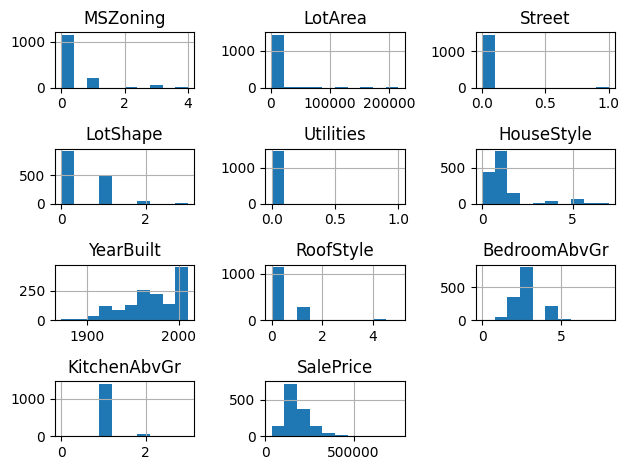

In [29]:
df.hist()
plt.tight_layout()

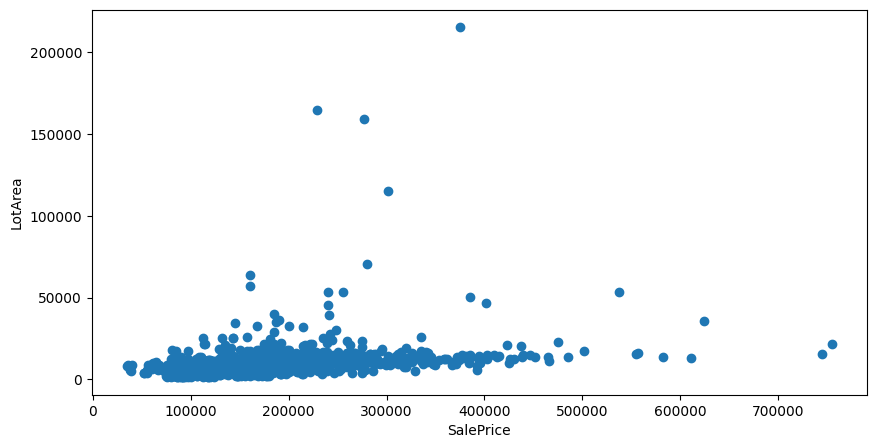

In [30]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(df['SalePrice'], df['LotArea'])
ax.set_xlabel('SalePrice')
ax.set_ylabel('LotArea')
plt.show()

,MSZoning,LotArea,Street,LotShape,Utilities,HouseStyle,YearBuilt,RoofStyle,BedroomAbvGr,KitchenAbvGr,SalePrice
MSZoning,1.000000,-0.161640,0.039678,-0.167918,-0.011167,-0.047199,-0.062684,-0.088537,-0.085901,0.073459,-0.116047
LotArea,-0.161640,1.000000,0.197131,0.315484,0.010123,-0.008187,0.014228,0.137369,0.119690,-0.017784,0.263843
Street,0.039678,0.197131,1.000000,0.010129,-0.001682,0.025328,-0.021137,0.006881,-0.028865,-0.013583,-0.041036
LotShape,-0.167918,0.315484,0.010129,1.000000,0.026616,-0.067647,0.229365,0.043063,0.060028,-0.094870,0.267759
Utilities,-0.011167,0.010123,-0.001682,0.026616,1.000000,0.076219,-0.011505,-0.011462,0.004288,-0.005536,-0.014314
HouseStyle,-0.047199,-0.008187,0.025328,-0.067647,0.076219,1.000000,-0.251479,0.005490,-0.097554,0.033279,-0.188688
YearBuilt,-0.062684,0.014228,-0.021137,0.229365,-0.011505,-0.251479,1.000000,-0.017865,-0.070651,-0.174800,0.522897
RoofStyle,-0.088537,0.137369,0.006881,0.043063,-0.011462,0.005490,-0.017865,1.000000,0.001679,-0.011240,0.159332
BedroomAbvGr,-0.085901,0.119690,-0.028865,0.060028,0.004288,-0.097554,-0.070651,0.001679,1.000000,0.198597,0.168213
KitchenAbvGr,0.073459,-0.017784,-0.013583,-0.094870,-0.005536,0.033279,-0.174800,-0.011240,0.198597,1.000000,-0.135907


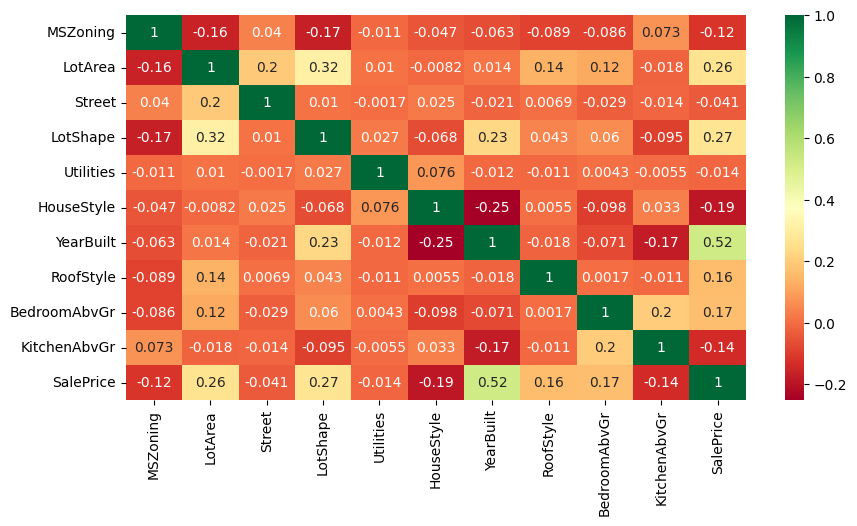

In [31]:
plt.figure(figsize=(10,5))
c = df.corr()
sns.heatmap(c, cmap="RdYlGn", annot=True)
c

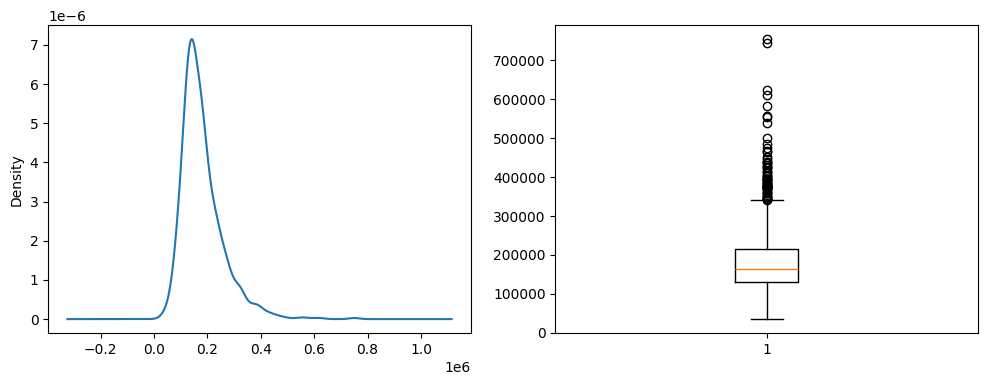

In [34]:
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['SalePrice'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['SalePrice'])
plt.show()

,MSZoning,LotArea,Street,LotShape,Utilities,HouseStyle,YearBuilt,RoofStyle,BedroomAbvGr,KitchenAbvGr,SalePrice
MSZoning,1.000000,-0.350854,0.037472,-0.155925,-0.011551,-0.057903,-0.060075,-0.076454,-0.076987,0.077918,-0.101646
LotArea,-0.350854,1.000000,0.006031,0.310973,0.045459,-0.013789,0.113575,0.154604,0.301627,-0.023872,0.428148
Street,0.037472,0.006031,1.000000,0.024430,-0.001272,0.030775,-0.005028,0.008264,-0.031062,-0.010028,-0.052408
LotShape,-0.155925,0.310973,0.024430,1.000000,0.030639,-0.060681,0.231836,-0.027997,0.037467,-0.101607,0.215845
Utilities,-0.011551,0.045459,-0.001272,0.030639,1.000000,0.079957,-0.012098,-0.012483,0.004546,-0.005785,-0.014874
HouseStyle,-0.057903,-0.013789,0.030775,-0.060681,0.079957,1.000000,-0.243700,-0.005657,-0.091160,0.034358,-0.210545
YearBuilt,-0.060075,0.113575,-0.005028,0.231836,-0.012098,-0.243700,1.000000,-0.021491,-0.061265,-0.184150,0.572776
RoofStyle,-0.076454,0.154604,0.008264,-0.027997,-0.012483,-0.005657,-0.021491,1.000000,0.026806,-0.035648,0.162177
BedroomAbvGr,-0.076987,0.301627,-0.031062,0.037467,0.004546,-0.091160,-0.061265,0.026806,1.000000,0.199371,0.161538
KitchenAbvGr,0.077918,-0.023872,-0.010028,-0.101607,-0.005785,0.034358,-0.184150,-0.035648,0.199371,1.000000,-0.145205


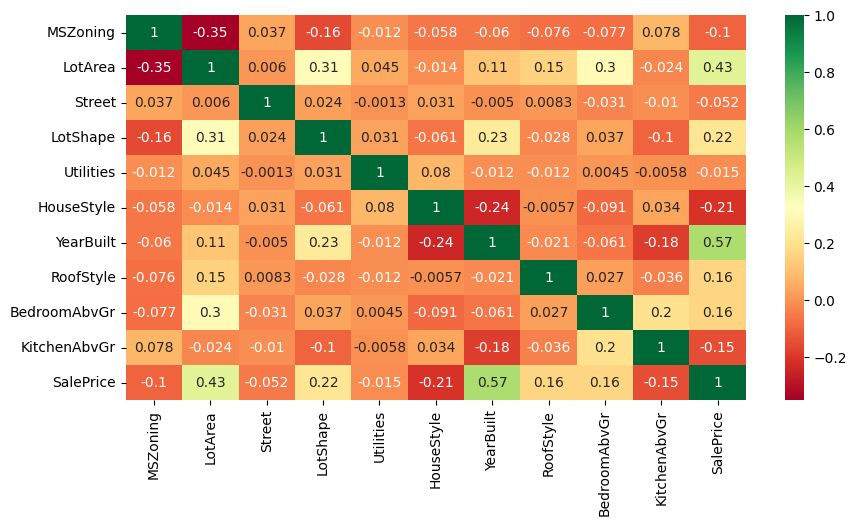

In [46]:
plt.figure(figsize=(10,5))
c = df.corr()
sns.heatmap(c, cmap="RdYlGn", annot=True)
c

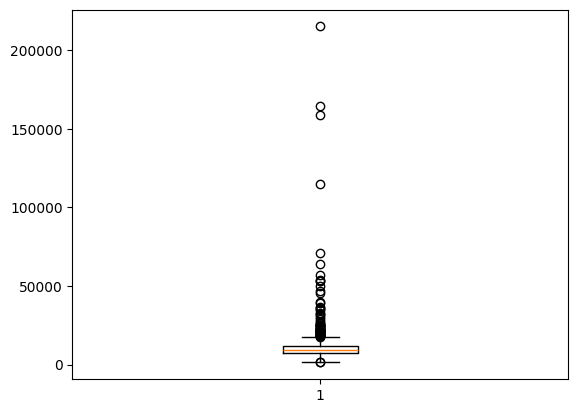

In [39]:
plt.boxplot(df['LotArea'])
plt.show()      

In [44]:
Q1 = df['LotArea'].quantile(0.25)
Q3 = df['LotArea'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['LotArea'] >= Q1 - 1.5*IQR) & 
        (df['LotArea'] <= Q3 + 1.5*IQR)]

In [45]:
df.copy()

,MSZoning,LotArea,Street,LotShape,Utilities,HouseStyle,YearBuilt,RoofStyle,BedroomAbvGr,KitchenAbvGr,SalePrice
0,0,8450,0,0,0,0,2003,0,3,1,208500
1,0,9600,0,0,0,1,1976,0,3,1,181500
2,0,11250,0,1,0,0,2001,0,3,1,223500
3,0,9550,0,1,0,0,1915,0,3,1,140000
4,0,14260,0,1,0,0,2000,0,4,1,250000
...,...,...,...,...,...,...,...,...,...,...,...
1455,0,7917,0,0,0,0,1999,0,3,1,175000
1456,0,13175,0,0,0,1,1978,0,3,1,210000
1457,0,9042,0,0,0,0,1941,0,4,1,266500
1458,0,9717,0,0,0,1,1950,1,2,1,142125


In [73]:
df['LotArea'].shape

(1357,)

In [55]:
x = df['LotArea'].values
y = df['SalePrice'].values

# mean
x_mean = np.mean(x)
y_mean = np.mean(y)

beta_1 = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
beta_0 = y_mean - beta_1 * x_mean

In [56]:
df['SalePrice_Pred'] = beta_0 + beta_1 * df['LotArea']

In [57]:
df[['LotArea', 'SalePrice', 'SalePrice_Pred']]

,LotArea,SalePrice,SalePrice_Pred
0,8450,208500,169958.929186
1,9600,181500,182268.749215
2,11250,223500,199930.664909
3,9550,140000,181733.539649
4,14260,250000,232150.280810
...,...,...,...
1455,7917,175000,164253.595208
1456,13175,210000,220536.233218
1457,9042,266500,176295.810453
1458,9717,142125,183521.139601


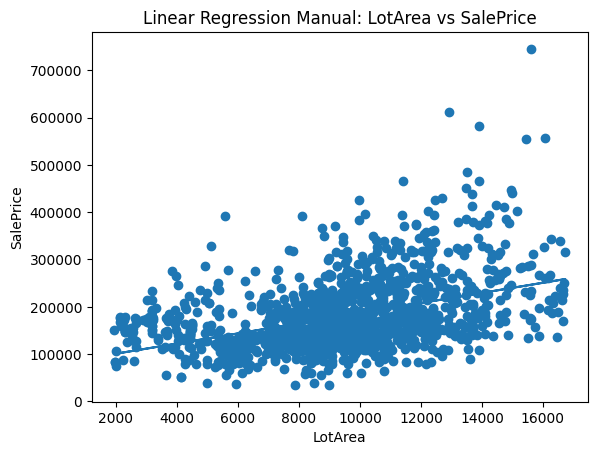

In [58]:
plt.figure()
plt.scatter(df['LotArea'], df['SalePrice'])
plt.plot(df['LotArea'], df['SalePrice_Pred'])
plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.title('Linear Regression Manual: LotArea vs SalePrice')
plt.show()

In [70]:
Q1 = df['LotArea'].quantile(0.25)
Q3 = df['LotArea'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['LotArea'] >= lower) & (df['LotArea'] <= upper)]


,MSZoning,LotArea,Street,LotShape,Utilities,HouseStyle,YearBuilt,RoofStyle,BedroomAbvGr,KitchenAbvGr,SalePrice,SalePrice_Pred
MSZoning,1.000000,-0.348019,0.037630,-0.154028,-0.011503,-0.059588,-0.059995,-0.075529,-0.073530,0.078524,-0.098830,-0.348019
LotArea,-0.348019,1.000000,0.005873,0.306709,0.046031,-0.009082,0.114473,0.154649,0.295552,-0.025402,0.425669,1.000000
Street,0.037630,0.005873,1.000000,0.024493,-0.001278,0.030945,-0.005016,0.008157,-0.031468,-0.010081,-0.052684,0.005873
LotShape,-0.154028,0.306709,0.024493,1.000000,0.030746,-0.058459,0.230778,-0.028558,0.030751,-0.102256,0.213295,0.306709
Utilities,-0.011503,0.046031,-0.001278,0.030746,1.000000,0.080345,-0.012094,-0.012554,0.004447,-0.005816,-0.015000,0.046031
HouseStyle,-0.059588,-0.009082,0.030945,-0.058459,0.080345,1.000000,-0.244348,-0.005427,-0.085075,0.034643,-0.209182,-0.009082
YearBuilt,-0.059995,0.114473,-0.005016,0.230778,-0.012094,-0.244348,1.000000,-0.021377,-0.063016,-0.184173,0.573763,0.114473
RoofStyle,-0.075529,0.154649,0.008157,-0.028558,-0.012554,-0.005427,-0.021377,1.000000,0.024832,-0.036180,0.161015,0.154649
BedroomAbvGr,-0.073530,0.295552,-0.031468,0.030751,0.004447,-0.085075,-0.063016,0.024832,1.000000,0.199601,0.156531,0.295552
KitchenAbvGr,0.078524,-0.025402,-0.010081,-0.102256,-0.005816,0.034643,-0.184173,-0.036180,0.199601,1.000000,-0.146278,-0.025402


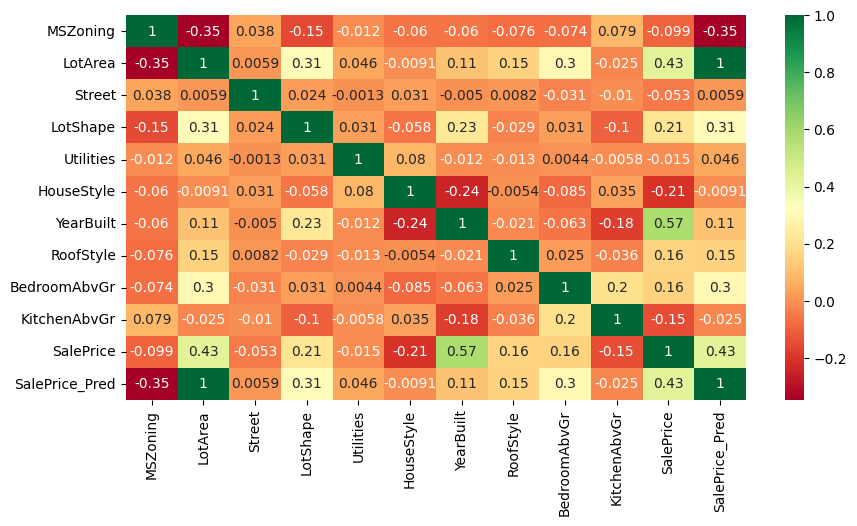

In [71]:
plt.figure(figsize=(10,5))
c = df.corr()
sns.heatmap(c, cmap="RdYlGn", annot=True)
c

In [72]:
df['LotArea'].shape

(1357,)

In [75]:
batas = df['SalePrice'].median()
batas


np.float64(162000.0)

In [76]:
df['KategoriHarga'] = np.where(
    df['SalePrice'] <= batas,
    'Murah',
    'Mahal'
)


In [78]:
df[['SalePrice', 'KategoriHarga']].head(10)


,SalePrice,KategoriHarga
0,208500,Mahal
1,181500,Mahal
2,223500,Mahal
3,140000,Murah
4,250000,Mahal
5,143000,Murah
6,307000,Mahal
7,200000,Mahal
8,129900,Murah
9,118000,Murah


In [79]:
df.groupby('KategoriHarga')['YearBuilt'].mean()


KategoriHarga
Mahal    1989.906667
Murah    1953.448680
Name: YearBuilt, dtype: float64

In [82]:
df

,MSZoning,LotArea,Street,LotShape,Utilities,HouseStyle,YearBuilt,RoofStyle,BedroomAbvGr,KitchenAbvGr,SalePrice,SalePrice_Pred,KategoriHarga
0,0,8450,0,0,0,0,2003,0,3,1,208500,169958.929186,Mahal
1,0,9600,0,0,0,1,1976,0,3,1,181500,182268.749215,Mahal
2,0,11250,0,1,0,0,2001,0,3,1,223500,199930.664909,Mahal
3,0,9550,0,1,0,0,1915,0,3,1,140000,181733.539649,Murah
4,0,14260,0,1,0,0,2000,0,4,1,250000,232150.280810,Mahal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0,7917,0,0,0,0,1999,0,3,1,175000,164253.595208,Mahal
1456,0,13175,0,0,0,1,1978,0,3,1,210000,220536.233218,Mahal
1457,0,9042,0,0,0,0,1941,0,4,1,266500,176295.810453,Mahal
1458,0,9717,0,0,0,1,1950,1,2,1,142125,183521.139601,Murah


In [83]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr


SalePrice         1.000000
YearBuilt         0.573763
LotArea           0.425669
SalePrice_Pred    0.425669
LotShape          0.213295
RoofStyle         0.161015
BedroomAbvGr      0.156531
Utilities        -0.015000
Street           -0.052684
MSZoning         -0.098830
KitchenAbvGr     -0.146278
HouseStyle       -0.209182
Name: SalePrice, dtype: float64

In [84]:
top_features = corr.index[1:4].tolist()
top_features


['YearBuilt', 'LotArea', 'SalePrice_Pred']

In [85]:
X = df[top_features]
y = df['SalePrice_Pred']


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [89]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [90]:
y_pred = knn.predict(X_test)

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae, rmse


(768.3956521481452, np.float64(1253.2206202550797))